In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
import math

In [2]:
avgspecs = pd.read_csv('./Average_Spectra_fixed.csv')
del avgspecs['Unnamed: 0']
avgspecs
normalized_specs = pd.read_csv('./normalized_specs.csv')
normalized_specs

,Wavelength (nm),Target Reflectance,foldername,reflectance_norm
0,339.3,27.1465,bent005ck,0.022807
1,340.8,26.8220,bent005ck,0.022534
2,342.3,26.1780,bent005ck,0.021993
3,343.7,25.4310,bent005ck,0.021366
4,345.2,24.9400,bent005ck,0.020953
...,...,...,...,...
15899,2504.7,35.3210,kao5ppfr,0.022700
15900,2506.7,35.3195,kao5ppfr,0.022699
15901,2508.8,35.3295,kao5ppfr,0.022705
15902,2510.9,35.3275,kao5ppfr,0.022704


# Adding things to the avg specs

In [3]:
for foldername in avgspecs['foldername'].unique():
    if 'pem' in foldername:
        avgspecs.loc[avgspecs['foldername']==foldername,'plastic'] = 'Polyethylene Mulch Film'
    if 'ck' in foldername:
        avgspecs.loc[avgspecs['foldername']==foldername,'plastic'] = 'Control'
    if 'ppfm' in foldername:
        avgspecs.loc[avgspecs['foldername']==foldername,'plastic'] = 'Polypropylene Flat Fragment'
    if 'ppfr' in foldername:
        avgspecs.loc[avgspecs['foldername']==foldername,'plastic'] = 'Polypropylene Fiber'
avgspecs

,Wavelength (nm),Target Reflectance,foldername,plastic
0,339.3,27.1465,bent005ck,Control
1,340.8,26.8220,bent005ck,Control
2,342.3,26.1780,bent005ck,Control
3,343.7,25.4310,bent005ck,Control
4,345.2,24.9400,bent005ck,Control
...,...,...,...,...
15899,2504.7,35.3210,kao5ppfr,Polypropylene Fiber
15900,2506.7,35.3195,kao5ppfr,Polypropylene Fiber
15901,2508.8,35.3295,kao5ppfr,Polypropylene Fiber
15902,2510.9,35.3275,kao5ppfr,Polypropylene Fiber


In [4]:
for foldername in normalized_specs['foldername'].unique():
    if 'pem' in foldername:
        normalized_specs.loc[normalized_specs['foldername']==foldername,'plastic'] = 'Polyethylene Mulch Film'
    if 'ck' in foldername:
        normalized_specs.loc[normalized_specs['foldername']==foldername,'plastic'] = 'Control'
    if 'ppfm' in foldername:
        normalized_specs.loc[normalized_specs['foldername']==foldername,'plastic'] = 'Polypropylene Flat Fragment'
    if 'ppfr' in foldername:
        normalized_specs.loc[normalized_specs['foldername']==foldername,'plastic'] = 'Polypropylene Fiber'
normalized_specs

,Wavelength (nm),Target Reflectance,foldername,reflectance_norm,plastic
0,339.3,27.1465,bent005ck,0.022807,Control
1,340.8,26.8220,bent005ck,0.022534,Control
2,342.3,26.1780,bent005ck,0.021993,Control
3,343.7,25.4310,bent005ck,0.021366,Control
4,345.2,24.9400,bent005ck,0.020953,Control
...,...,...,...,...,...
15899,2504.7,35.3210,kao5ppfr,0.022700,Polypropylene Fiber
15900,2506.7,35.3195,kao5ppfr,0.022699,Polypropylene Fiber
15901,2508.8,35.3295,kao5ppfr,0.022705,Polypropylene Fiber
15902,2510.9,35.3275,kao5ppfr,0.022704,Polypropylene Fiber


# Average Spectra without the atmospheric bands highlighted

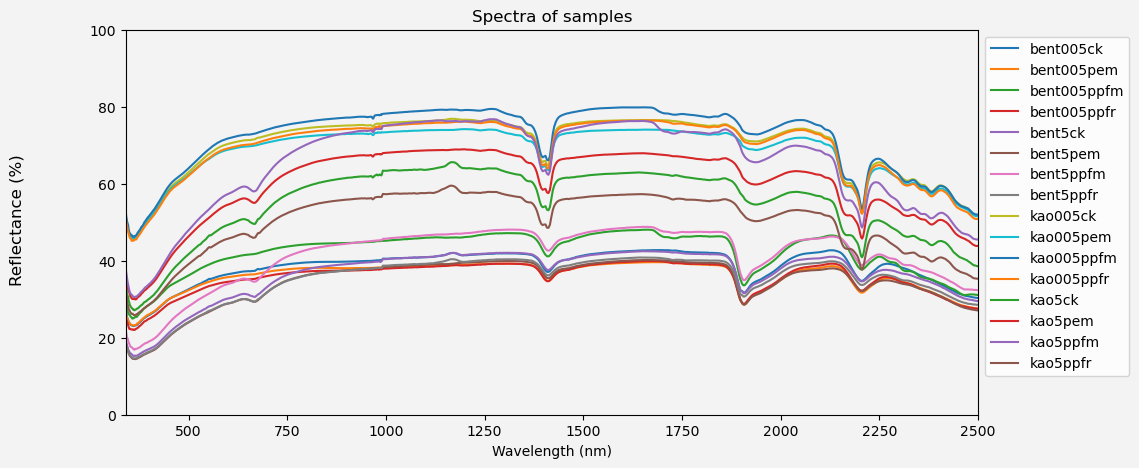

In [5]:
#to create the figure base
fig, ax = plt.subplots(1,1,figsize=(11,5),sharex=True,sharey=True)

#Labeling the axes and title
ax.set_xlabel('Wavelength (nm)')
fig.supylabel('Reflectance (%)')
ax.set_title('Spectra of samples')
ax.set_xlim(340,2500)#(1000,1500)
ax.set_ylim(0,100)
for i,foldername in enumerate(avgspecs['foldername'].unique()):
    ax.plot(avgspecs[avgspecs['foldername']==foldername]['Wavelength (nm)'],avgspecs[avgspecs['foldername']==foldername]['Target Reflectance'],label=foldername) #plots each average spectrum vs the wavelength

# ax.fill_betweenx(y=(0,100), x1=1344, x2=1433, color='r',alpha = 0.2, label='Atmospheric Bands from AVIRIS')
# ax.fill_betweenx(y=(0,100), x1=1788, x2=1966, color='r',alpha = 0.2)
ax.set_facecolor('#f3f3f3')  # changing the color of the axes
fig.set_facecolor('#f3f3f3')  # changing the color of the figure
ax.legend(loc=2,bbox_to_anchor=(1, 1))#, ncol=2)
plt.savefig('./Figures/avgspec_without_atmo.png', bbox_inches='tight')
plt.show()

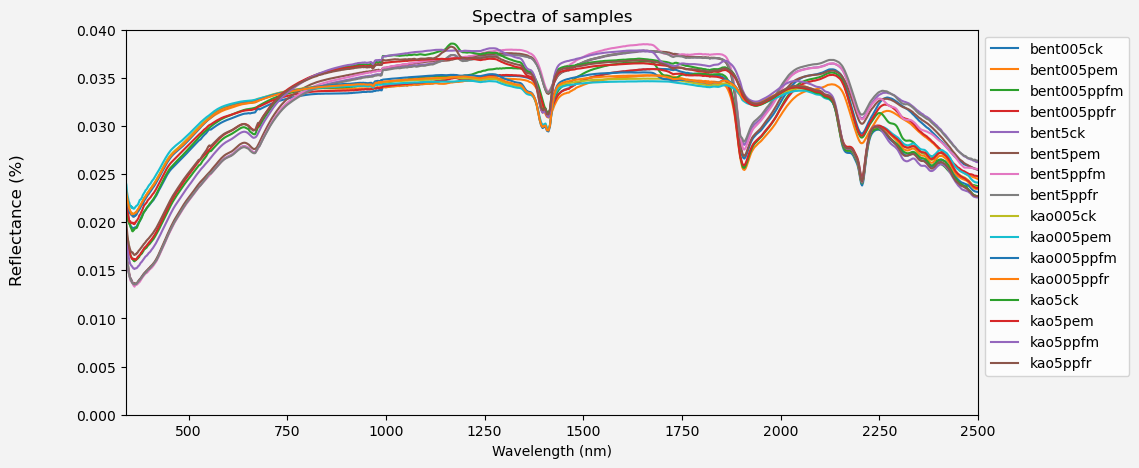

In [6]:
#to create the figure base
fig, ax = plt.subplots(1,1,figsize=(11,5),sharex=True,sharey=True)

#Labeling the axes and title
ax.set_xlabel('Wavelength (nm)')
fig.supylabel('Reflectance (%)')
ax.set_title('Spectra of samples')
ax.set_xlim(340,2500)#(1000,1500)
ax.set_ylim(0,0.04)
for i,foldername in enumerate(normalized_specs['foldername'].unique()):
    ax.plot(normalized_specs[normalized_specs['foldername']==foldername]['Wavelength (nm)'],normalized_specs[normalized_specs['foldername']==foldername]['reflectance_norm'],label=foldername) #plots each average spectrum vs the wavelength

# ax.fill_betweenx(y=(0,100), x1=1344, x2=1433, color='r',alpha = 0.2, label='Atmospheric Bands from AVIRIS')
# ax.fill_betweenx(y=(0,100), x1=1788, x2=1966, color='r',alpha = 0.2)

ax.set_facecolor('#f3f3f3')  # changing the color of the axes
fig.set_facecolor('#f3f3f3')  # changing the color of the figure
ax.legend(loc=2,bbox_to_anchor=(1, 1))#, ncol=2)
plt.savefig('./Figures/normalspec_without_atmo.png', bbox_inches='tight')
plt.show()

# %Change in absorption feature depth

In [7]:
normalized_avg_absorptions = pd.read_csv('normalized_avg_absorptions.csv')
avg_absorptions = pd.read_csv('avg_absorptions.csv')
normalized_avg_absorptions

,Wavelength (nm),absorption_amplitude,band_depth,foldername,%_change
0,2204.0,0.004469,0.132706,bent005ck,NaN
1,2204.0,0.004062,0.125866,bent005pem,-9.101908
2,2206.4,0.004124,0.125265,bent005ppfm,-7.713801
3,2206.4,0.004089,0.123578,bent005ppfr,-8.499114
4,2206.4,0.003625,0.105320,bent5ck,NaN
5,2206.4,0.003546,0.105009,bent5pem,-2.186715
6,2206.4,0.003544,0.103511,bent5ppfm,-2.251165
7,2206.4,0.003583,0.103073,bent5ppfr,-1.158981
8,2206.4,0.005560,0.187432,kao005ck,NaN
9,2206.4,0.005211,0.175406,kao005pem,-6.274471


In [8]:
for foldername in normalized_avg_absorptions['foldername'].unique():
    if 'pem' in foldername:
        normalized_avg_absorptions.loc[normalized_avg_absorptions['foldername']==foldername,'plastic'] = 'Polyethylene Mulch Film'
    if 'ck' in foldername:
        normalized_avg_absorptions.loc[normalized_avg_absorptions['foldername']==foldername,'plastic'] = 'Control'
    if 'ppfm' in foldername:
        normalized_avg_absorptions.loc[normalized_avg_absorptions['foldername']==foldername,'plastic'] = 'Polypropylene Flat Fragment'
    if 'ppfr' in foldername:
        normalized_avg_absorptions.loc[normalized_avg_absorptions['foldername']==foldername,'plastic'] = 'Polypropylene Fiber'
normalized_avg_absorptions

,Wavelength (nm),absorption_amplitude,band_depth,foldername,%_change,plastic
0,2204.0,0.004469,0.132706,bent005ck,NaN,Control
1,2204.0,0.004062,0.125866,bent005pem,-9.101908,Polyethylene Mulch Film
2,2206.4,0.004124,0.125265,bent005ppfm,-7.713801,Polypropylene Flat Fragment
3,2206.4,0.004089,0.123578,bent005ppfr,-8.499114,Polypropylene Fiber
4,2206.4,0.003625,0.105320,bent5ck,NaN,Control
5,2206.4,0.003546,0.105009,bent5pem,-2.186715,Polyethylene Mulch Film
6,2206.4,0.003544,0.103511,bent5ppfm,-2.251165,Polypropylene Flat Fragment
7,2206.4,0.003583,0.103073,bent5ppfr,-1.158981,Polypropylene Fiber
8,2206.4,0.005560,0.187432,kao005ck,NaN,Control
9,2206.4,0.005211,0.175406,kao005pem,-6.274471,Polyethylene Mulch Film


In [4]:
avg_abs_plot = avg_absorptions[~avg_absorptions['foldername'].str.contains('ck')]
avg_abs_plot.loc[:,'color']='b'
avg_abs_plot.loc[avg_abs_plot['%_change']<0,['color']]='r'

/tmp/ipykernel_100/1542021892.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  avg_abs_plot.loc[:,'color']='b'


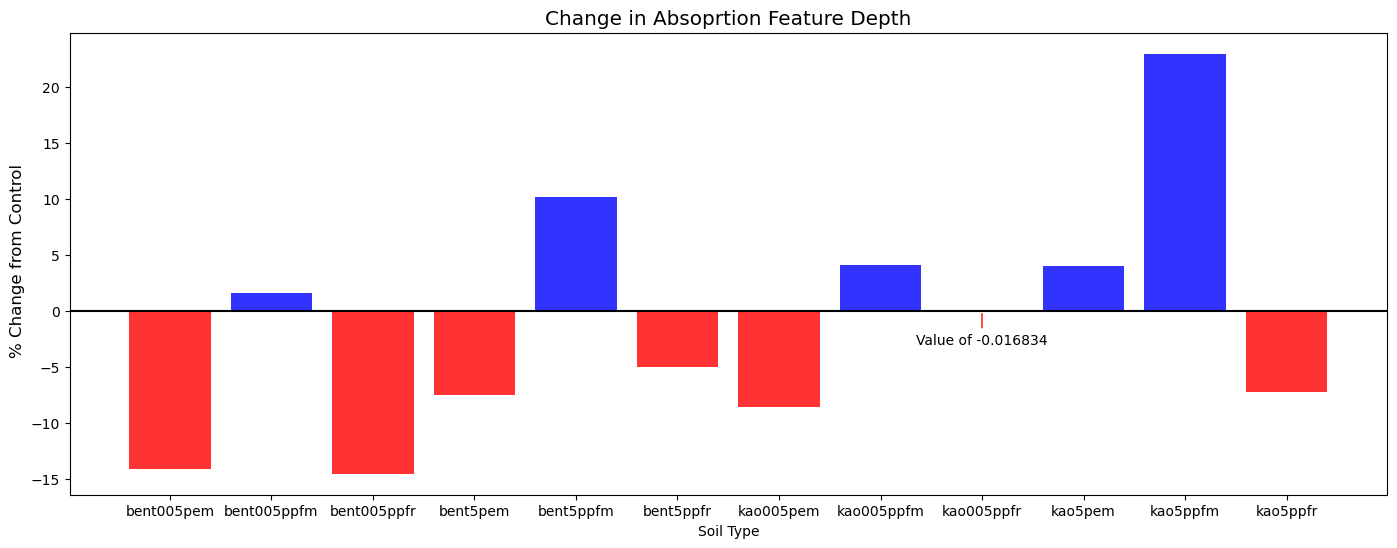

In [7]:
#to create the figure base
fig, ax = plt.subplots(1,1,figsize=(17,6),sharex=True,sharey=True)

#Labeling the axes and title
ax.set_xlabel('Soil Type')
fig.supylabel('% Change from Control',x=0.09)
ax.set_title('Change in Absoprtion Feature Depth',weight = 550,size='x-large')


ax.axhline(y=0, color='k')
ax.bar(avg_abs_plot['foldername'], avg_abs_plot['%_change'], color=avg_abs_plot['color'],alpha = 0.8)
ax.annotate('Value of -0.016834', ('kao005ppfr',0), xytext=('kao005ppfr',-3), ha='center', arrowprops={'arrowstyle': '-', 'color': 'r'})
#plt.savefig('./Figures/.png')
plt.show()

In [9]:
n_avg_abs_plot = normalized_avg_absorptions[~normalized_avg_absorptions['foldername'].str.contains('ck')]
n_avg_abs_plot.loc[:,'color']='#4285f4'
n_avg_abs_plot.loc[n_avg_abs_plot['%_change']<0,['color']]='tomato' 

/tmp/ipykernel_113/2046358796.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  n_avg_abs_plot.loc[:,'color']='#4285f4'


In [10]:
n_avg_abs_plot

,Wavelength (nm),absorption_amplitude,band_depth,foldername,%_change,plastic,color
1,2204.0,0.004062,0.125866,bent005pem,-9.101908,Polyethylene Mulch Film,tomato
2,2206.4,0.004124,0.125265,bent005ppfm,-7.713801,Polypropylene Flat Fragment,tomato
3,2206.4,0.004089,0.123578,bent005ppfr,-8.499114,Polypropylene Fiber,tomato
5,2206.4,0.003546,0.105009,bent5pem,-2.186715,Polyethylene Mulch Film,tomato
6,2206.4,0.003544,0.103511,bent5ppfm,-2.251165,Polypropylene Flat Fragment,tomato
7,2206.4,0.003583,0.103073,bent5ppfr,-1.158981,Polypropylene Fiber,tomato
9,2206.4,0.005211,0.175406,kao005pem,-6.274471,Polyethylene Mulch Film,tomato
10,2206.4,0.005650,0.191735,kao005ppfm,1.618820,Polypropylene Flat Fragment,#4285f4
11,2206.4,0.005621,0.189267,kao005ppfr,1.108501,Polypropylene Fiber,#4285f4
13,2206.4,0.005336,0.178281,kao5pem,-4.862060,Polyethylene Mulch Film,tomato


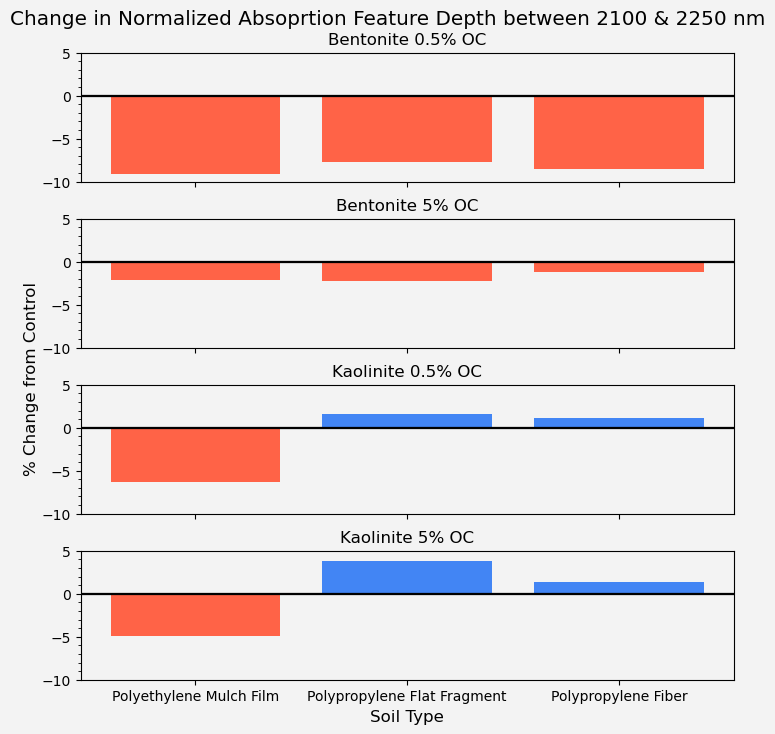

In [11]:
#to create the figure base
fig, ax = plt.subplots(4,1,figsize=(7,7),sharex=True,sharey=True,constrained_layout=True)

#Labeling the axes and title
ax[-1].set_xlabel('Soil Type',size='large')
fig.supylabel('% Change from Control',x=-0.02,size='larger',weight=550)
fig.supxlabel('Change in Normalized Absoprtion Feature Depth between 2100 & 2250 nm',weight = 550,size='x-large',y=1)
ax[0].set_ylim(-10,5)
ax[0].yaxis.set_minor_locator(ticker.AutoMinorLocator())
fig.set_facecolor('#f3f3f3')  # changing the color of the figure
ax[0].set_facecolor('#f3f3f3')  # changing the color of the axes
ax[1].set_facecolor('#f3f3f3')  # changing the color of the axes
ax[2].set_facecolor('#f3f3f3')  # changing the color of the axes
ax[3].set_facecolor('#f3f3f3')  # changing the color of the axes

for soiltype in n_avg_abs_plot['foldername'].unique():
    if 'bent005' in soiltype:
        ax[0].axhline(y=0, color='k') #creating a line in the middle of the plot
        ax[0].bar(n_avg_abs_plot.loc[n_avg_abs_plot['foldername']==soiltype,'plastic'], n_avg_abs_plot.loc[n_avg_abs_plot['foldername']==soiltype,'%_change'], color=n_avg_abs_plot.loc[n_avg_abs_plot['foldername']==soiltype,'color']) #plotting the data
        ax[0].set_title('Bentonite 0.5% OC')
    if 'bent5' in soiltype:
        ax[1].axhline(y=0, color='k') #creating a line in the middle of the plot
        ax[1].bar(n_avg_abs_plot.loc[n_avg_abs_plot['foldername']==soiltype,'plastic'], n_avg_abs_plot.loc[n_avg_abs_plot['foldername']==soiltype,'%_change'], color=n_avg_abs_plot.loc[n_avg_abs_plot['foldername']==soiltype,'color']) #plotting the data
        ax[1].set_title('Bentonite 5% OC')
    if 'kao005' in soiltype:
        ax[2].axhline(y=0, color='k') #creating a line in the middle of the plot
        ax[2].bar(n_avg_abs_plot.loc[n_avg_abs_plot['foldername']==soiltype,'plastic'], n_avg_abs_plot.loc[n_avg_abs_plot['foldername']==soiltype,'%_change'], color=n_avg_abs_plot.loc[n_avg_abs_plot['foldername']==soiltype,'color']) #plotting the data
        ax[2].set_title('Kaolinite 0.5% OC')
    if 'kao5' in soiltype:
        ax[3].axhline(y=0, color='k') #creating a line in the middle of the plot
        ax[3].bar(n_avg_abs_plot.loc[n_avg_abs_plot['foldername']==soiltype,'plastic'], n_avg_abs_plot.loc[n_avg_abs_plot['foldername']==soiltype,'%_change'], color=n_avg_abs_plot.loc[n_avg_abs_plot['foldername']==soiltype,'color']) #plotting the data
        ax[3].set_title('Kaolinite 5% OC')   
plt.savefig('./Figures/Change_in_Normalized_Absoprtion_Feature_Depth.png', bbox_inches='tight')

plt.show()

# Spectra by soil type

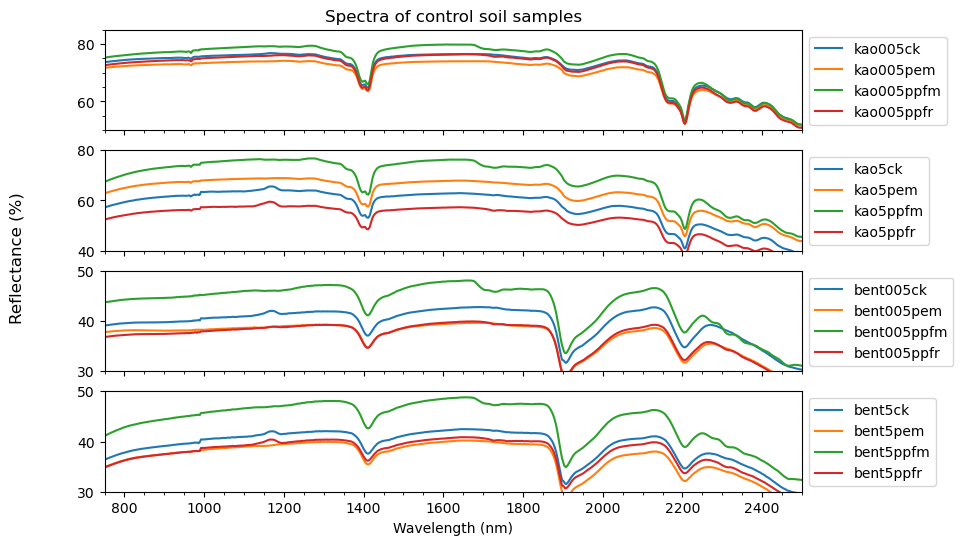

In [9]:
fig, ax = plt.subplots(4,1,figsize=(9,6),sharex=True,sharey=False) #figure parameters and size
ax[-1].set_xlabel('Wavelength (nm)')
fig.supylabel('Reflectance (%)')
ax[0].set_title('Spectra of control soil samples')
ax[0].yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax[0].xaxis.set_minor_locator(ticker.AutoMinorLocator())

for soiltype in avgspecs['foldername'].unique():
    if soiltype in avgspecs[avgspecs['foldername'].str.contains('bent005')]['foldername'].unique():
        ax[0].plot(avgspecs['Wavelength (nm)'].unique(),avgspecs[avgspecs['foldername']==soiltype]['Target Reflectance'],label=soiltype)
        ax[0].set_xlim(750,2500)#(1000,1500)
        ax[0].set_ylim(50,85)
        ax[0].legend(loc=2,bbox_to_anchor=(1, 1))
    if soiltype in avgspecs[avgspecs['foldername'].str.contains('bent5')]['foldername'].unique():
        ax[1].plot(avgspecs['Wavelength (nm)'].unique(),avgspecs[avgspecs['foldername']==soiltype]['Target Reflectance'],label=soiltype)
        ax[1].set_xlim(750,2500)#(1000,1500)
        ax[1].set_ylim(40,80)
        ax[1].legend(loc=2,bbox_to_anchor=(1, 1))
    if soiltype in avgspecs[avgspecs['foldername'].str.contains('kao005')]['foldername'].unique():
        ax[2].plot(avgspecs['Wavelength (nm)'].unique(),avgspecs[avgspecs['foldername']==soiltype]['Target Reflectance'],label=soiltype)
        ax[2].set_xlim(750,2500)#(1000,1500)
        ax[2].set_ylim(30,50)
        ax[2].legend(loc=2,bbox_to_anchor=(1, 1))
    if soiltype in avgspecs[avgspecs['foldername'].str.contains('kao5')]['foldername'].unique():
        ax[3].plot(avgspecs['Wavelength (nm)'].unique(),avgspecs[avgspecs['foldername']==soiltype]['Target Reflectance'],label=soiltype)
        ax[3].set_xlim(750,2500)#(1000,1500)
        ax[3].set_ylim(30,50)
        ax[3].legend(loc=2,bbox_to_anchor=(1, 1))
plt.show()

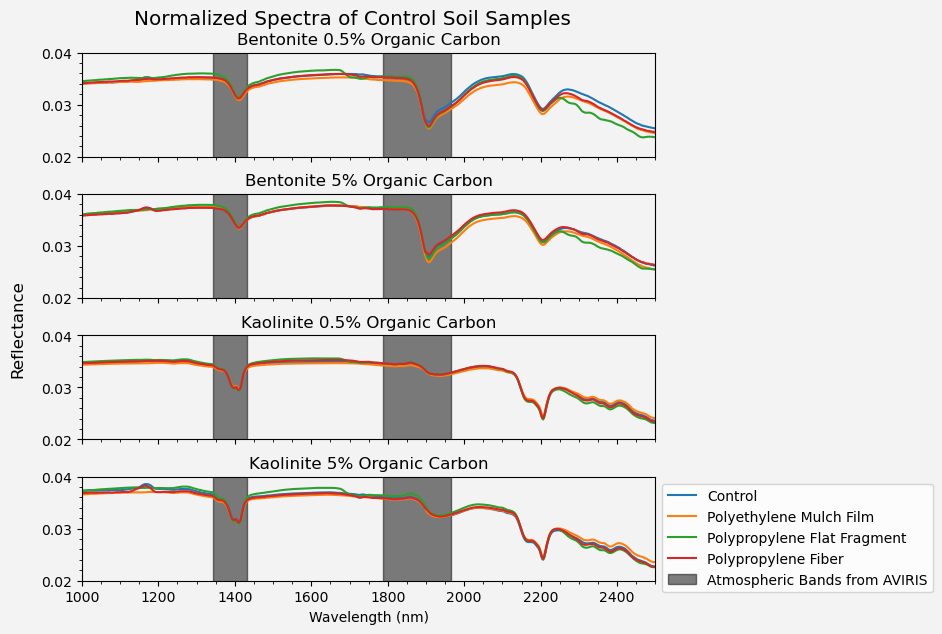

In [36]:
#This is the normalized spec not avg



fig, ax = plt.subplots(4,1,figsize=(9,6),sharex=True,sharey=True,constrained_layout=True) #figure parameters and size
ax[-1].set_xlabel('Wavelength (nm)')
fig.supylabel('Reflectance',x=-0.03)
fig.supxlabel('Normalized Spectra of Control Soil Samples',x=0.35,y=1,size='x-large')
ax[0].yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax[0].xaxis.set_minor_locator(ticker.AutoMinorLocator())
fig.set_facecolor('#f3f3f3')  # changing the color of the figure

for soiltype in normalized_specs['foldername'].unique():
    if soiltype in normalized_specs[normalized_specs['foldername'].str.contains('bent005')]['foldername'].unique():
        ax[0].plot(normalized_specs['Wavelength (nm)'].unique(),normalized_specs[normalized_specs['foldername']==soiltype]['reflectance_norm'])
        ax[0].set_title('Bentonite 0.5% Organic Carbon')
    if soiltype in normalized_specs[normalized_specs['foldername'].str.contains('bent5')]['foldername'].unique():
        ax[1].plot(normalized_specs['Wavelength (nm)'].unique(),normalized_specs[normalized_specs['foldername']==soiltype]['reflectance_norm'])
        ax[1].set_title('Bentonite 5% Organic Carbon')
    if soiltype in normalized_specs[normalized_specs['foldername'].str.contains('kao005')]['foldername'].unique():
        ax[2].plot(normalized_specs['Wavelength (nm)'].unique(),normalized_specs[normalized_specs['foldername']==soiltype]['reflectance_norm'])
        ax[2].set_title('Kaolinite 0.5% Organic Carbon')
    if soiltype in normalized_specs[normalized_specs['foldername'].str.contains('kao5')]['foldername'].unique():
        ax[3].plot(normalized_specs['Wavelength (nm)'].unique(),normalized_specs[normalized_specs['foldername']==soiltype]['reflectance_norm'],label=normalized_specs[normalized_specs['foldername']==soiltype]['plastic'].unique())
        ax[3].set_title('Kaolinite 5% Organic Carbon')
for i in range(4):
    ax[i].fill_betweenx(y=(0,100), x1=1788, x2=1966, color='k',alpha = 0.5,label='Atmospheric Bands from AVIRIS')
    ax[i].fill_betweenx(y=(0,100), x1=1344, x2=1433, color='k',alpha = 0.5,) #label='Atmospheric Bands from AVIRIS')
    ax[i].set_xlim(1000,2500)#(1000,1500)
    ax[i].set_facecolor('#f3f3f3')  # changing the color of the axes
ax[3].legend(loc=2,bbox_to_anchor=(1, 1))
ax[0].set_ylim(0.02,.04)
plt.savefig('./Figures/normalized_spec_separated.png', bbox_inches='tight')
plt.show()

# Average Spectra of Fields


In [38]:
# Need to bring in the data from ENVI ROI, normalize it, and then plot it
ROI_data = pd.read_csv('./data/fieldROIstats.txt',sep='	',engine='python')

In [39]:
ROI_data = ROI_data.rename(columns={'      Min': 'Min','      Max': 'Max','     Mean': 'Mean','   Stdev': 'Stdev','Basic Stats':'Wavelength (nm)'})

In [40]:
wavelengths = []
for i in range(380,2500,5):
    wavelengths.append(i)
for i,wavelength in enumerate(ROI_data['Wavelength (nm)'].unique()):
    ROI_data.loc[ROI_data['Wavelength (nm)']==wavelength,'Wavelength (nm)'] = wavelengths[i]

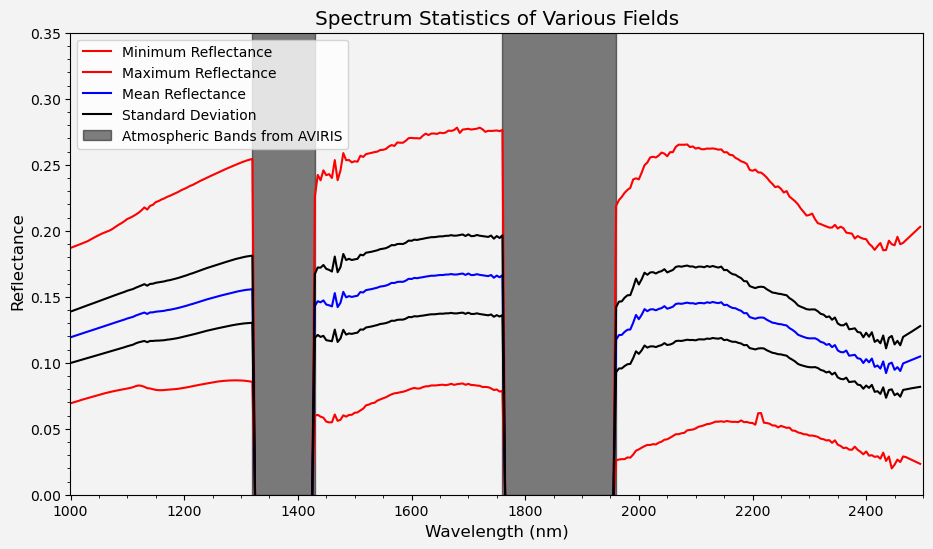

In [56]:
fig, ax = plt.subplots(1,1,figsize=(11,6),sharex=True,sharey=True)
#Labeling the axes and title
ax.set_xlabel('Wavelength (nm)',size='large')
fig.supylabel('Reflectance',x=0.07,size='large')
ax.set_title('Spectrum Statistics of Various Fields',size='x-large')
ax.set_xlim(1000,2500)#(1000,1500)
ax.set_ylim(0,0.35)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.plot(ROI_data['Wavelength (nm)'],ROI_data['Min'],color='r',label='Minimum Reflectance')
ax.plot(ROI_data['Wavelength (nm)'],ROI_data['Max'],color='r',label='Maximum Reflectance')
ax.plot(ROI_data['Wavelength (nm)'],ROI_data['Mean'],color='blue',label='Mean Reflectance')
ax.plot(ROI_data['Wavelength (nm)'],(ROI_data['Mean']+ROI_data['Stdev']),color='k',label='Standard Deviation')
ax.plot(ROI_data['Wavelength (nm)'],(ROI_data['Mean']-ROI_data['Stdev']),color='k')
ax.fill_betweenx(y=(0,1), x1=1760, x2=1960, color='k',alpha = 0.5,label='Atmospheric Bands from AVIRIS')
ax.fill_betweenx(y=(0,1), x1=1320, x2=1430, color='k',alpha = 0.5)
#ax.legend(loc=2,bbox_to_anchor=(1, 1))
ax.legend(loc=2)
ax.set_facecolor('#f3f3f3')  # changing the color of the axes
fig.set_facecolor('#f3f3f3')  # changing the color of the figure
plt.savefig('./Figures/Field_spectra_stats.png', bbox_inches='tight')
plt.show()

# next fig